# Examining how the pipeline performs with each detected combination.

- Let's examine one of each manually and make the pipeline work for them.
- 3sml: hd18256
- 2sm: hd10072
- 2ml: hd16673
- 1m: hd11131
- 0: hd10700

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

SEED = 1701
error_percent = 5

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


## 2sm: HD10072


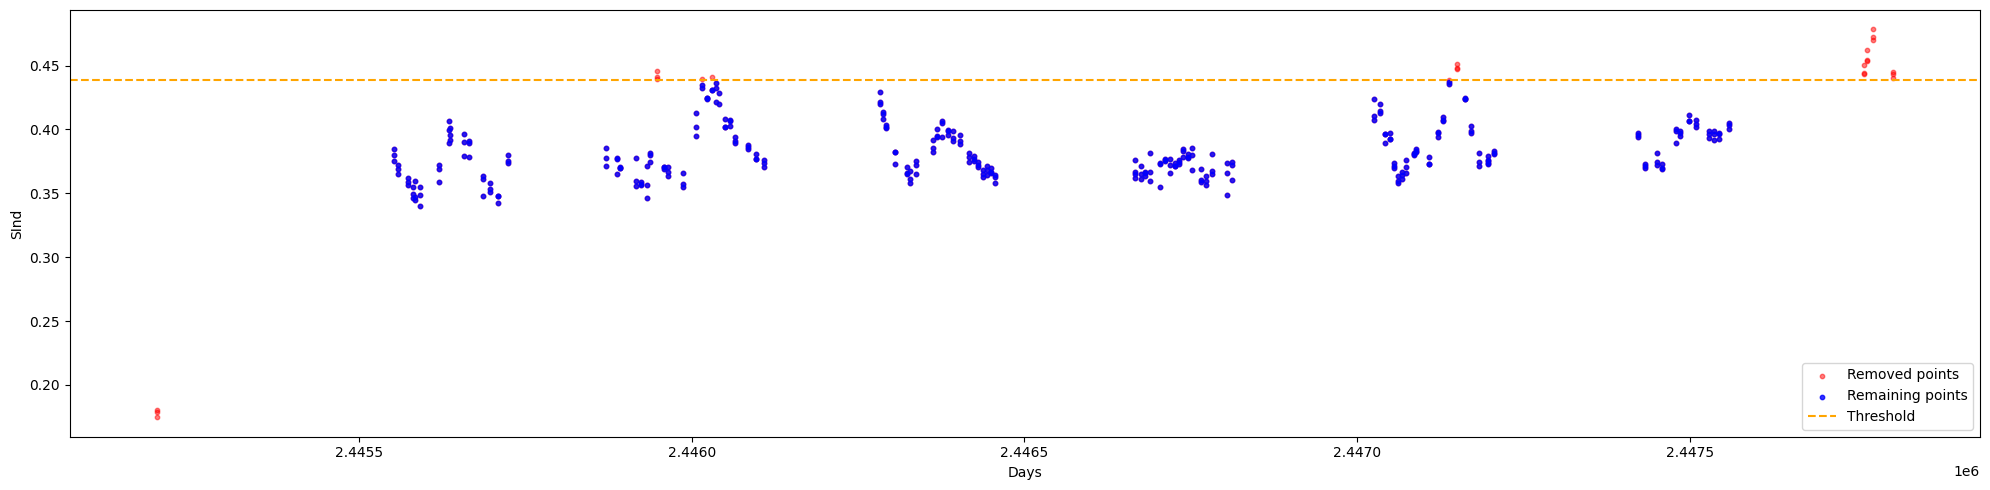

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1516.69 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 767.70 days was identified to be an alias of 1516.69 days at mult 0.50 by tolerance 0.01.
Peak at period 350.14 days was identified to be a window of 365.25 days by tolerance 0.04.
Peak at period 190.63 days was identified to be a window of 182.62 days by tolerance 0.04.
In iteration 1, period at 561.47 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 726.09 days was identified to be an alias of 1516.69 days at mult 0.50 by tolerance 0.04.
Peak at period 351.96 days was identified to be a window of 365.25 days by tolerance 0.04.
Peak at period 189.17 days was identified to be an alias of 561.47 days at mult 0.33 by tolerance 0.01.
In iteration 2, period at 56.68 day

In [7]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd10072_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, dirty_valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df, valid_df, _ = clean_df(dirty_train_df, dirty_valid_df, tol=4,
                        verbose=False, plot=True)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=False, verbose_fitpeaks=False,
                                        plot_genpriors=False, verbose_genpriors=True)

- Found all three so the priors should be the same.

In [8]:
# Get the concomitant priors
star_type = "G"
priors = get_priors(classified_signal_data,
                                        star_type=star_type,
                                        verbose=True)

+------------+------------+-------------+-----------------------------------------------------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |                           Bounds Days                           |  Bounds Years  | Source |
+------------+------------+-------------+-----------------------------------------------------------------+----------------+--------+
|   Short    |   56.68    |     0.16    |  [np.float64(53.84164021640217), np.float64(59.50918129181292)] |  (0.15, 0.16)  | found  |
|    Mid     |  1516.69   |     4.16    | [np.float64(1440.8517103171032), np.float64(1592.520311403114)] |  (3.95, 4.36)  | found  |
|    Long    |  36500.00  |    100.00   |                            [1, 73000]                           | (0.00, 200.00) |  mean  |
+------------+------------+-------------+-----------------------------------------------------------------+----------------+--------+


- Let's see how well it predicts.

In [9]:
require_mid = True
sigma_upper_mult = 5
rho_bound_mults = [0.9, 1.1]
q_bounds_in = [5, 10]
loop_verbose = False
loop_plot = False
loop_savefigs = False
star_name = "HD10072"
results_verbose = True
results_plot = True
ax = None

In [ ]:
# #-----Do the model training and comparison---------
# train_yerr = train_df['sind'] * error_percent / 100

# train_mean = train_df['sind'].mean()
# train_std  = train_df['sind'].std()

# # Define the prior combos to try
# prior_combos = {
# "1s":   (1, [priors['short']]),
# "1m":   (1, [priors['mid']]),
# "1l":   (1, [priors['long']]),

# "2sm":  (2, [priors['short'], priors['mid']]),
# "2ml":  (2, [priors['mid'],   priors['long']]),
# "2ls":  (2, [priors['long'],  priors['short']]),

# "3sml": (3, [priors['short'], priors['mid'], priors['long']]),
# }

# if require_mid:
#         prior_combos = {k: v for k, v in prior_combos.items() if priors['mid'] in v[1]}

# # Set up the loop
# best_combo  = None
# best_NLPD   = np.inf
# best_gp     = None
# best_params = None

# # Run the loop
# for combo_name, (k, prior_combo) in prior_combos.items():
#         np.random.seed(SEED)

#         sigma_0s = [train_std / k for _ in range(k)]
#         rho_0s   = prior_combo
#         q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

#         initial_guess = np.concatenate([
#                 np.log(sigma_0s),
#                 np.log(rho_0s),
#                 np.log(q_0s)
#         ])

#         sigma_upper  = train_std * sigma_upper_mult
#         sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
#         rho_bounds   = [(np.log(rho * rho_bound_mults[0]), np.log(rho * rho_bound_mults[1])) for rho in rho_0s]
#         q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

#         bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

#         # Create the initial kernel for this iteration
#         kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
#         for k_idx in range(1, k):
#                 kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

#         # Define and compute the GP
#         gp = celerite2.GaussianProcess(kernel, mean=train_mean)
#         gp.compute(train_df['day'], yerr=train_yerr)

#         # Train the GP
#         gp_results = minimize(
#                 NLL, initial_guess,
#                 args=(gp, k, train_df['sind'].to_numpy()),
#                 method='L-BFGS-B',
#                 bounds=bounds
#                 )

#         gp   = set_params(gp_results.x, k, gp)
#         gp.recompute()
#         best = np.exp(gp_results.x)

#         if loop_verbose:
#                 table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
#                 best_sigmas = best[0:k]
#                 best_rhos   = best[k:2*k]
#                 best_qs     = best[2*k:]
#                 for k_idx in range(k):
#                         table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
#                                         f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
#                 print(gp_results.success, gp_results.message)
#                 print(f"For k = {k}")
#                 print(table)

#         # Predict on validation set
#         mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
#         std = np.sqrt(cov)

#         # Model comparison via NLPD
#         y_valid    = valid_df['sind'].to_numpy()
#         valid_yerr = valid_df['sind'] * error_percent / 100
#         total_var  = cov + valid_yerr**2
#         nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
#         mean_nlpd = nlpd_per_point.mean()

#         if mean_nlpd < best_NLPD:
#                 best_combo  = combo_name
#                 best_NLPD   = mean_nlpd
#                 best_gp     = gp
#                 best_params = best

#         if loop_plot:
#                 loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
#                 loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
#                 loop_ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                
#                 loop_ax.set_title(star_name + " " + combo_name)

#                 loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
#                 loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
#                                         color='green', alpha=0.2, label='Uncertainties')
                
#                 loop_ax.legend()

#                 loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
#                         transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
#                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
#                 if loop_savefigs:
#                         loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
#                         plt.close(loop_fig)

#                 else:
#                         plt.show()

#         if loop_verbose:
#                 print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")

# #-------Now we have the best model------

# # Predict the best model once
# mu, cov = best_gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
# std = np.sqrt(cov)
# results = pd.DataFrame({
#         'forecast': mu,
#         'lower':    mu - std,
#         'upper':    mu + std,
# }, index=valid_df.index)

# if results_verbose: # Print best model params
#         print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
#         (k, prior_combo) = prior_combos[best_combo]
#         table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
#         best_sigmas = best_params[0:k]
#         best_rhos   = best_params[k:2*k]
#         best_qs     = best_params[2*k:]
#         for k_idx in range(k):
#                 table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
#                                 f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
#         print(table)

# if results_plot: # Plot best model predictions
#         if ax is None: # Enables passthrough
#                 fig, ax = plt.subplots(figsize=(20, 5))
#         ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
#         ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
#         ax.set_title(f"Best model for {star_name} is {best_combo}")
#         ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
#         ax.fill_between(valid_df['year'], results['lower'], results['upper'],
#                         color='green', alpha=0.2, label='Uncertainties')
#         ax.legend()
#         ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
#                 transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
#                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

TypeError: tuple indices must be integers or slices, not str

- Ok this is pretty decent.
- Let's do the window analysis on this. 
- Because this used an unwrapped version of train_gpr, let's just use the GPR window function from GPR10.


1/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 777.92 days was accepted.
In iteration 1, period at 106.68 days was accepted.
The best params were found for 1m with NLPD of -2.4335898500278637.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0001 | 5.00 |   700.13   |     1.92    |
+--------+------+------------+-------------+
2/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 36493.79 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36492.70 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36490.51 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36489.78 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36485.76 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36484.30 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.84 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.11 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36480.29 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36475.91 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at pe

...

Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1269.21 days was accepted.
Peak at period 124.93 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 186.62 days was identified to be a window of 182.62 days by tolerance 0.02.
Peak at period 353.06 days was identified to be a window of 365.25 days by tolerance 0.03.
Period of 66.53 days has SNR of 4.085637689917451 < 5.
Period of 99.75 days has SNR of 3.9697636476537137 < 5.
Iteration 1 did not find a frequency: terminating loop.
The best params were found for 3sml with NLPD of -2.1996364678164597.
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0107 | 10.00 |    0.05    |     0.00    |
| 0.0072 | 10.00 |  1142.29   |     3.13    |
| 0.0001 |  5.00 |  37877.90  |    103.78   |
+--------+-------+------------+-------------+
9/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 299.40 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 1, period at 772.08 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 188.81 days was identified to be an alias of 772.08 days at mult 0.25 by tolerance 0.02.
In iteration 2, period at 346.85 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 3, period at 273.49 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 559.65 days was identified to be an alias of 273.49 days at mult 2.00 by tolerance 0.02.
In iteration 4, period at 229.32 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by to

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Period of 397.22 days has SNR of 4.639367148272055 < 5.
Period of 300.50 days has SNR of 4.751720763588044 < 5.
In iteration 0, period at 1547.71 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 396.13 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.02.
In iteration 1, period at 567.68 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 399.41 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.03.
Peak at period 354.15 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 2, period at 700.54 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 350.87 days was identified to be an alias of 700.54

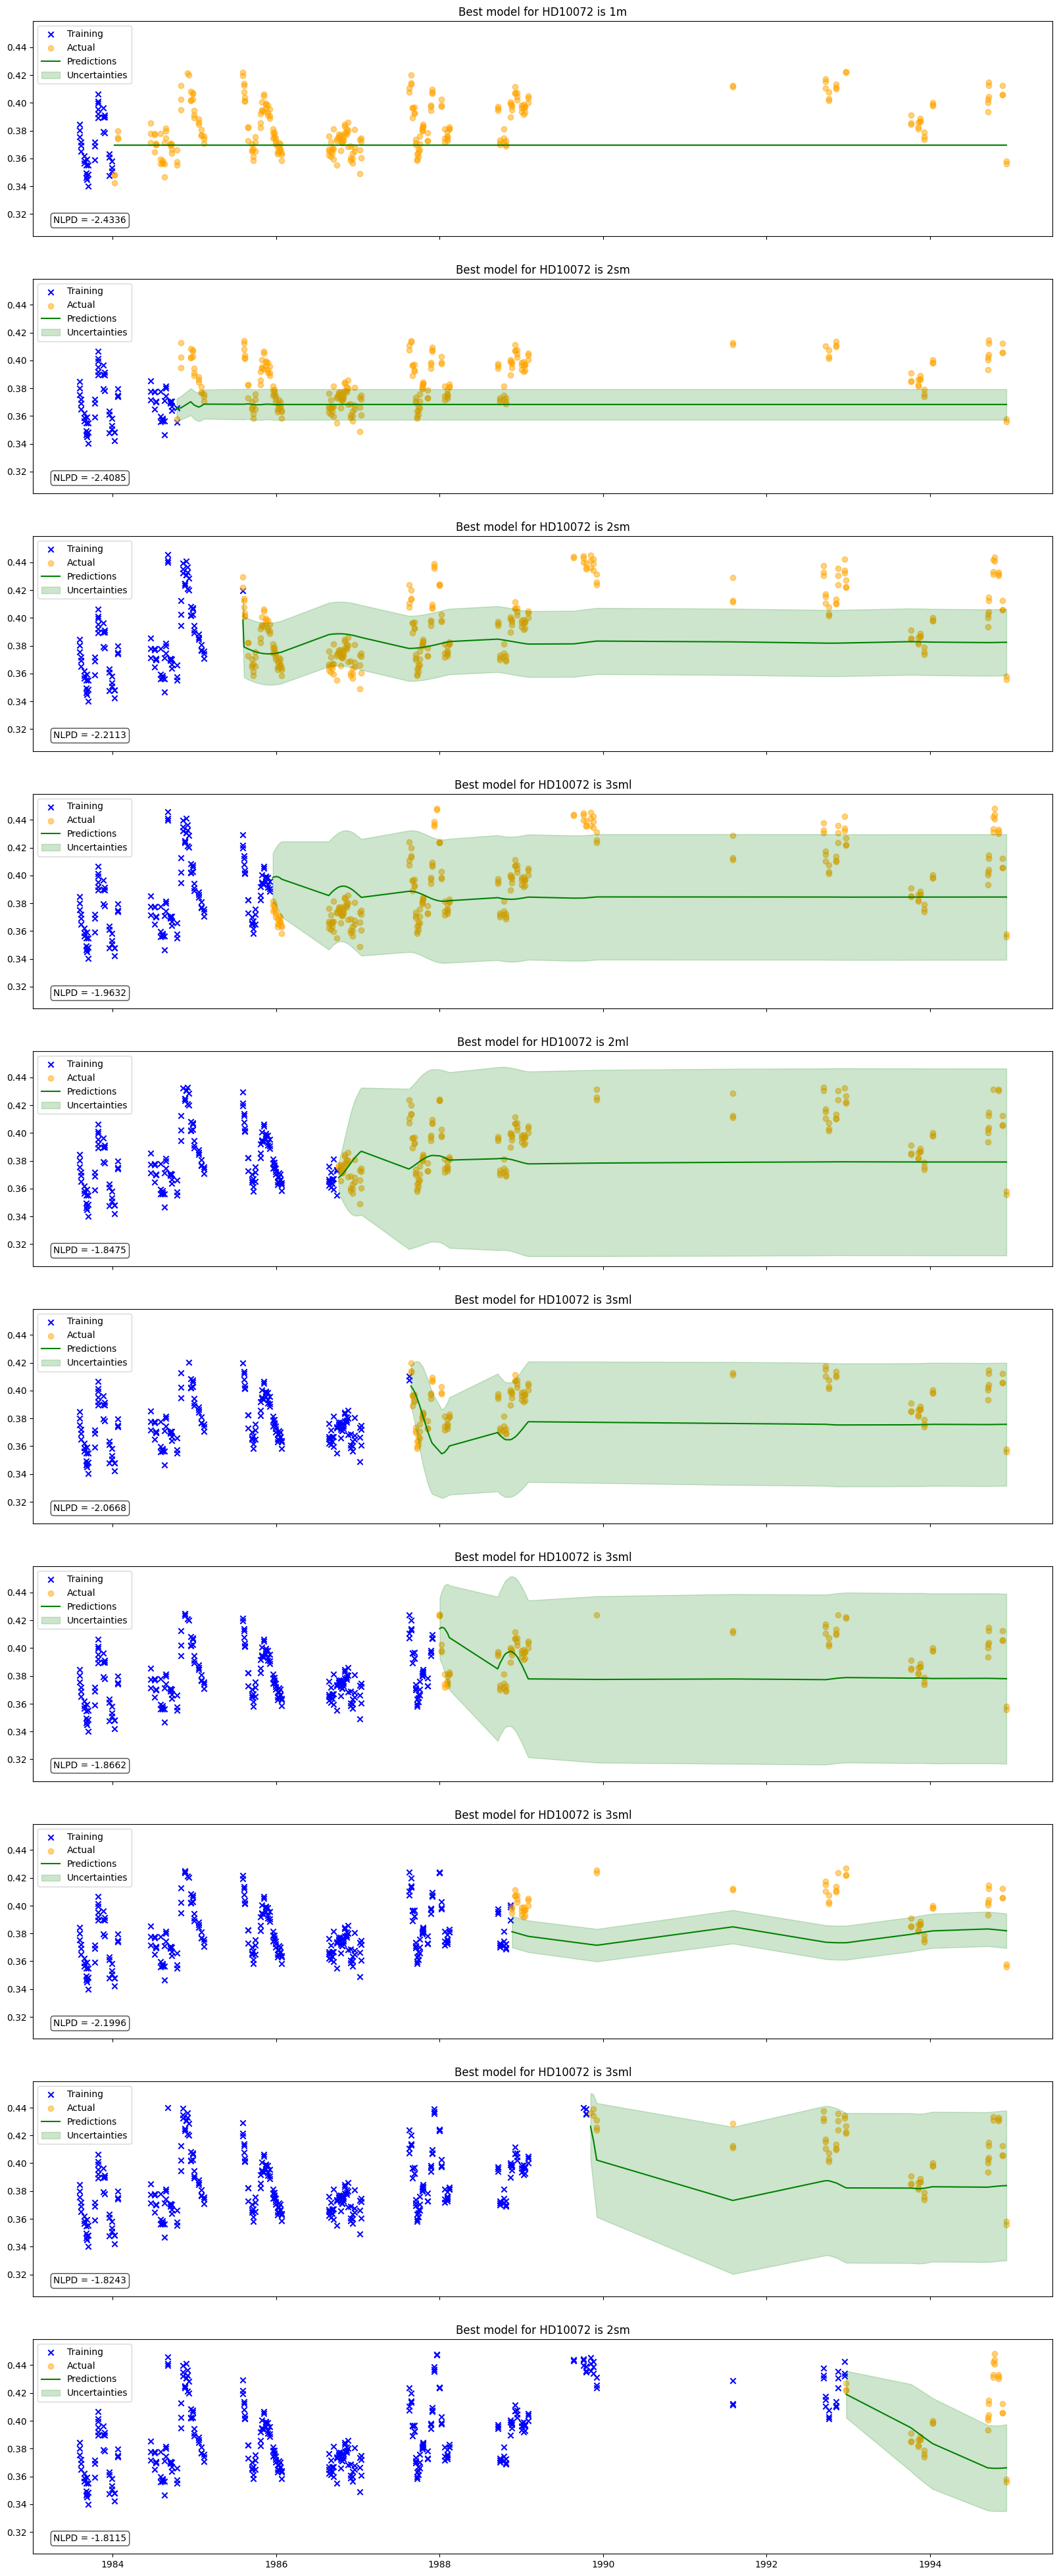

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))
from helpers.gpr import train_gpr

def plot_moving_window(n_windows=10, train_low=0.1, train_high=0.9):
    fig, ax = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, train_split in enumerate(train_splits):
        print(f"{idx+1}/{n_windows}")
        valid_split = 0.99 - train_split
        train_gpr(
            datapath         = datapath,
            add_prefix       = add_prefix,
            relative         = relative,
            train_split      = train_split,
            valid_split      = valid_split,
            star_name        = star_name,
            star_type        = star_type,
            error_percent    = error_percent,
            sigma_upper_mult = sigma_upper_mult,
            rho_bound_mults  = rho_bound_mults,
            q_bounds_in      = q_bounds_in,
            require_mid      = require_mid,
            verbose          = False,
            plot             = False,
            loop_verbose     = loop_verbose,
            loop_plot        = loop_plot,
            loop_savefigs    = loop_savefigs,
            results_verbose  = results_verbose,
            results_plot     = results_plot,
            ax               = ax[idx],
            SEED             = SEED,
        )

    plt.savefig(f"moving_window_{star_name}")

plot_moving_window()

- I think this indicates to us that it might be worth fitting a flat kernel as well.
- This would require the model comparison to adapt to different priors and kernels.
- Return priors should now also return the prior bounds. This allows us to tune how tight they are for different prior estimation methods.
- Then the prior combos should now look like "1s": ("spectrum", None ,[1, [priors[short]]]) where the kernel type is in front and the bounds to be used is None indicating that the bounds fed in from the prior generating function should be used.
- Actually the best way I can think of implementing a flat kernel is by having a very very overdamped SHOTerm. So the k = 1, priors = whatever we have and bounds will have q well into the overdamped regime (very small).

In [ ]:
from helpers.priors import SM2016_m_to_s, SM2016_s_to_m

def get_priors(classified_signal_data, star_type, verbose = True,
                        direct_bound_tol = 0.05, # For regular go between 0.95 and 1.05
                        sm2016_bound_tol = 0.2, # 0.8 to 1.2
                        mean_bound_tol = 1, # 1 std: make sure to correct for lower bound max(0, mean-meanboundtol*std)
               ):
        '''
        This takes in the input of the find_classify_signals function
        and outputs the three priors. One in each range.count
        Fills in missing ones using the SM2016 relationship.
        Fills in missing long-term priors with 100 year guess.

        Returns the priors and the bounds. Bounds are based on what tolerance we want for mean and SM2016.
        Mean comes from a table with stds. Define mean bounds as standard deviations allowed.
        SM2016 should be percentage based.
        '''
        #------- Define the means and standard deviations that are fallbacks------------
        mu_Pmids = { # THESE COME FROM SM2016
        'F':  {'mean_yr': 9.5,  'mean_days': 9.5  * 365, 'std_yr': 5.3, 'std_days': 5.3 * 365},
        'G':  {'mean_yr': 6.7,  'mean_days': 6.7  * 365, 'std_yr': 3.6, 'std_days': 3.6 * 365},
        'K':  {'mean_yr': 8.5,  'mean_days': 8.5  * 365, 'std_yr': 3.6, 'std_days': 3.6 * 365},
        'ME': {'mean_yr': 6.0,  'mean_days': 6.0  * 365, 'std_yr': 2.9, 'std_days': 2.9 * 365},
        'MM': {'mean_yr': 7.1,  'mean_days': 7.1  * 365, 'std_yr': 2.7, 'std_days': 2.7 * 365},
        }  # P_cyc


        mu_Pshorts = {  # THESE COME FROM SM2016
        'F':  {'mean_yr': 8.6  / 365, 'mean_days': 8.6,  'std_yr': 6.2  / 365, 'std_days': 6.2},
        'G':  {'mean_yr': 19.6 / 365, 'mean_days': 19.6, 'std_yr': 11.1 / 365, 'std_days': 11.1},
        'K':  {'mean_yr': 27.4 / 365, 'mean_days': 27.4, 'std_yr': 15.7 / 365, 'std_days': 15.7},
        'ME': {'mean_yr': 36.2 / 365, 'mean_days': 36.2, 'std_yr': 29.9 / 365, 'std_days': 29.9},
        'MM': {'mean_yr': 85.4 / 365, 'mean_days': 85.4, 'std_yr': 53.4 / 365, 'std_days': 53.4},
        }  # P_rot

        #------ Now choose which ones to return----------

        # If has all three then return all three
        short = classified_signal_data.get('short', np.nan)
        mid = classified_signal_data.get('mid', np.nan)
        long = classified_signal_data.get('long', np.nan)

        # Use detected if available, otherwise use SM2016 if available, else use mean for that star type
        def _resolve(direct, derive, default, std):
                # If there is a direct detection from LSP method
                if not np.isnan(direct):
                        direct_bounds = [direct * (1 - direct_bound_tol), direct * (1 + direct_bound_tol)]
                        return direct, direct_bounds, 'found'
                
                # Otherwise check if SM2016 possible
                derived = derive()

                if derived is not None: #SM2016
                        sm2016_bounds = [derived * (1 - sm2016_bound_tol), derived * (1 + sm2016_bound_tol)]
                        return derived, sm2016_bounds, 'SM2016'
                
                # Otherwise use mean as defined in paper
                default_bounds = [max(1, default - (mean_bound_tol * std)), default + (mean_bound_tol * std)]

                return default, default_bounds, 'mean'

        short_val, short_bounds, short_src = _resolve(
                                                short,
                                                lambda: SM2016_m_to_s(mid, star_type) if not np.isnan(mid) else None,
                                                mu_Pshorts[star_type]['mean_days'], std = mu_Pshorts[star_type]['std_days']
                                                )
        mid_val, mid_bounds, mid_src = _resolve(
                                                mid,
                                                lambda: SM2016_s_to_m(short, star_type) if not np.isnan(short) else None,
                                                mu_Pmids[star_type]['mean_days'], std = mu_Pmids[star_type]['std_days']
                                                )
        long_val, long_bounds, long_src = _resolve(
                                                long, 
                                                lambda: None, 
                                                100 * 365, std = 100*365
                                                )

        #------Form priors and bounds to return--------

        rho_priors = {'short': short_val, 'mid': mid_val, 'long': long_val}

        # These are prios on periods so they are limited by rho_bounds
        rho_bounds = {'short': short_bounds, 'mid': mid_bounds, 'long': long_bounds}

        # Sources
        sources = {'short': short_src, 'mid': mid_src, 'long': long_src}

        if verbose:
                table = PrettyTable(["Cycle Type", "Prior Days", "Prior Years", "Bounds Days", "Bounds Years", "Source"])
                table.add_row(["Short", f"{rho_priors.get('short'):.2f}", f"{rho_priors.get('short')/365:.2f}", f"{rho_bounds.get('short')}", f"({rho_bounds.get('short')[0]/365:.2f}, {rho_bounds.get('short')[1]/365:.2f})", short_src])
                table.add_row(["Mid",   f"{rho_priors.get('mid'):.2f}",   f"{rho_priors.get('mid')/365:.2f}",   f"{rho_bounds.get('mid')}",   f"({rho_bounds.get('mid')[0]/365:.2f}, {rho_bounds.get('mid')[1]/365:.2f})",   mid_src])
                table.add_row(["Long",  f"{rho_priors.get('long'):.2f}",  f"{rho_priors.get('long')/365:.2f}",  f"{rho_bounds.get('long')}",  f"({rho_bounds.get('long')[0]/365:.2f}, {rho_bounds.get('long')[1]/365:.2f})",  long_src])
                print(table)

        return rho_priors, rho_bounds, sources 


def train_gpr(
        datapath, 
        direct_bound_tol = 0.1, sm2016_bound_tol = 0.2, 
        mean_bound_tol = 1, # in std
        add_prefix: bool = False, # whether or not to add the 240000 to the JD
        train_split: float = 0.8, valid_split: float = 0.19,
        star_type: str = None, star_name: str = None,
        error_percent: float = 2.5, # the percentage error of the input
        sigma_upper_mult: float = 5.0, q_bounds_in = [5, 100],
        relative: bool = True, # Plot data with relative dates
        verbose = True, plot = True, # general outputs
        loop_verbose: bool = False, loop_plot: bool = False, loop_savefigs: bool = True, # output within the loop
        results_verbose: bool = True, results_plot: bool = True, ax = None, # output the results
        require_mid: bool = True, # discard kernel combos with no mid-range term (prevents underfitting with sparse data)
        SEED = 1701
        ):
      
        # Read the data into a "raw" df
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

        # Prep the df adds the column names etc
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

        # Split the data
        dirty_train_df, dirty_valid_df, test_df = split_df(data_df,
                                                     train_split=train_split, valid_split=valid_split)

        # Clean the dataset for outliers
        train_df, valid_df, _ = clean_df(dirty_train_df, dirty_valid_df, tol=4,
                                verbose=verbose, plot=plot)

        # Classify signal data and get priors
        classified_signal_data = find_classify_signals(dirty_train_df,
                                                plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                                plot_genpriors=plot, verbose_genpriors=verbose)
        
        rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                                        star_type=star_type,
                                                                        direct_bound_tol = direct_bound_tol, 
                                                                        sm2016_bound_tol = sm2016_bound_tol, 
                                                                        mean_bound_tol = mean_bound_tol,
                                                                        verbose=verbose)

        #-----Do the model training and comparison---------
        train_yerr = train_df['sind'] * error_percent / 100

        train_mean = train_df['sind'].mean()
        train_std  = train_df['sind'].std()

        # Define the prior combos to try (k, [[q_priors], [rho_priors]])
        prior_combos = {
                "1s":    {'k': 1, 'q_priors': None,          'cycle_keys': ['short']},
                "1m":    {'k': 1, 'q_priors': None,          'cycle_keys': ['mid']},
                "1l":    {'k': 1, 'q_priors': None,          'cycle_keys': ['long']},

                "2sm":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'mid']},
                "2ml":   {'k': 2, 'q_priors': None,          'cycle_keys': ['mid',   'long']},
                "2sl":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'long']},

                "3sml":  {'k': 3, 'q_priors': None,          'cycle_keys': ['short', 'mid', 'long']},

                "const": {'k': 1, 'q_priors': "overdamped",  'cycle_keys': ['mid']},
        }

        if require_mid:
                prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

        # Set up the loop
        best_combo  = None
        best_NLPD   = np.inf
        best_gp     = None
        best_params = None

        # Run the loop
        for combo_name, combo_info in prior_combos.items():
                k = combo_info['k']
                q_prior_type = combo_info['q_priors']
                cycle_keys = combo_info['cycle_keys']
                
                np.random.seed(SEED)

                #---- q priors----
                if q_prior_type == 'overdamped':
                        q_0s     = [np.random.uniform(0, 0.5) for _ in range(k)]
                else:
                        q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

                #---remaining priors----
                sigma_0s = [train_std / k for _ in range(k)]
                rho_0s = [rho_priors[cycle_key] for cycle_key in cycle_keys]

                initial_guess = np.concatenate([
                        np.log(sigma_0s),
                        np.log(rho_0s),
                        np.log(q_0s)
                ])

                #----q bounds-----
                if q_prior_type == 'overdamped':
                        q_bounds     = [(-np.inf, np.log(0.5)) for _ in range(k)]
                else:
                        q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

                sigma_upper  = train_std * sigma_upper_mult
                sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
                rho_bounds   = np.log([rho_prior_bounds[cycle_key] for cycle_key in cycle_keys])

                bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

                # Create the initial kernel for this iteration
                kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                for k_idx in range(1, k):
                        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

                # Define and compute the GP
                gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                gp.compute(train_df['day'], yerr=train_yerr)

                # Train the GP
                gp_results = minimize(
                        NLL, initial_guess,
                        args=(gp, k, train_df['sind'].to_numpy()),
                        method='L-BFGS-B',
                        bounds=bounds
                        )

                gp   = set_params(gp_results.x, k, gp)
                gp.recompute()
                best = np.exp(gp_results.x)

                if loop_verbose:
                        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                        best_sigmas = best[0:k]
                        best_rhos   = best[k:2*k]
                        best_qs     = best[2*k:]
                        for k_idx in range(k):
                                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                               f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                        print(gp_results.success, gp_results.message)
                        print(f"For k = {k}")
                        print(table)

                # Predict on validation set
                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                std = np.sqrt(cov)

                # Model comparison via NLPD
                y_valid    = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var  = cov + valid_yerr**2
                nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
                mean_nlpd = nlpd_per_point.mean()

                if mean_nlpd < best_NLPD:
                        best_combo  = combo_name
                        best_NLPD   = mean_nlpd
                        best_gp     = gp
                        best_params = best

                if loop_plot:
                        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                        
                        loop_ax.set_title(star_name + " " + combo_name)

                        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                        loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                             color='green', alpha=0.2, label='Uncertainties')
                        
                        loop_ax.legend()

                        loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                                transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                        
                        if loop_savefigs:
                                loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                                plt.close(loop_fig)

                        else:
                                plt.show()

                if loop_verbose:
                        print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")

        #-------Now we have the best model------

        # Predict the best model once
        mu, cov = best_gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        std = np.sqrt(cov)
        results = pd.DataFrame({
                'forecast': mu,
                'lower':    mu - std,
                'upper':    mu + std,
        }, index=valid_df.index)

        if results_verbose: # Print best model params
                print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
                k = prior_combos[best_combo]['k']
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best_params[0:k]
                best_rhos   = best_params[k:2*k]
                best_qs     = best_params[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                       f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(table)

        if results_plot: # Plot best model predictions
                if ax is None: # Enables passthrough
                        fig, ax = plt.subplots(figsize=(20, 5))
                ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                ax.set_title(f"Best model for {star_name} is {best_combo}")
                ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
                ax.fill_between(valid_df['year'], results['lower'], results['upper'],
                                color='green', alpha=0.2, label='Uncertainties')
                ax.legend()
                ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        return best_gp

1/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 777.92 days was accepted.
In iteration 1, period at 106.68 days was accepted.
The best params were found for 1m with NLPD of -2.4335898500278637.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0001 | 5.00 |   700.13   |     1.92    |
+--------+------+------------+-------------+
2/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 36493.79 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36492.70 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36490.51 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36489.78 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36485.76 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36484.30 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.84 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.11 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36480.29 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36475.91 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at pe

...

Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1269.21 days was accepted.
Peak at period 124.93 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 186.62 days was identified to be a window of 182.62 days by tolerance 0.02.
Peak at period 353.06 days was identified to be a window of 365.25 days by tolerance 0.03.
Period of 66.53 days has SNR of 4.085637689917451 < 5.
Period of 99.75 days has SNR of 3.9697636476537137 < 5.
Period of 228.59 days has SNR of 2.0288113537316437 < 5.
Peak at period 93.91 days was identified to be a window of 91.31 days by tolerance 0.03.
Iteration 1 did not find a frequency: terminating loop.
The best params were found for 3sml with NLPD of -2.1996364678164597.
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0107 | 10.00 |    0.05    |     0.00    |
| 0.0072 | 10.00

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 299.40 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 1, period at 772.08 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 188.81 days was identified to be an alias of 772.08 days at mult 0.25 by tolerance 0.02.
In iteration 2, period at 346.85 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 3, period at 273.49 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 559.65 days was identified to be an alias of 273.49 days at mult 2.00 by tolerance 0.02.
In iteration 4, period at 229.32 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by to

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Period of 397.22 days has SNR of 4.639367148272055 < 5.
Period of 300.50 days has SNR of 4.751720763588044 < 5.
In iteration 0, period at 1547.71 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 396.13 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.02.
In iteration 1, period at 567.68 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 399.41 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.03.
Peak at period 354.15 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 2, period at 700.54 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 350.87 days was identified to be an alias of 700.54

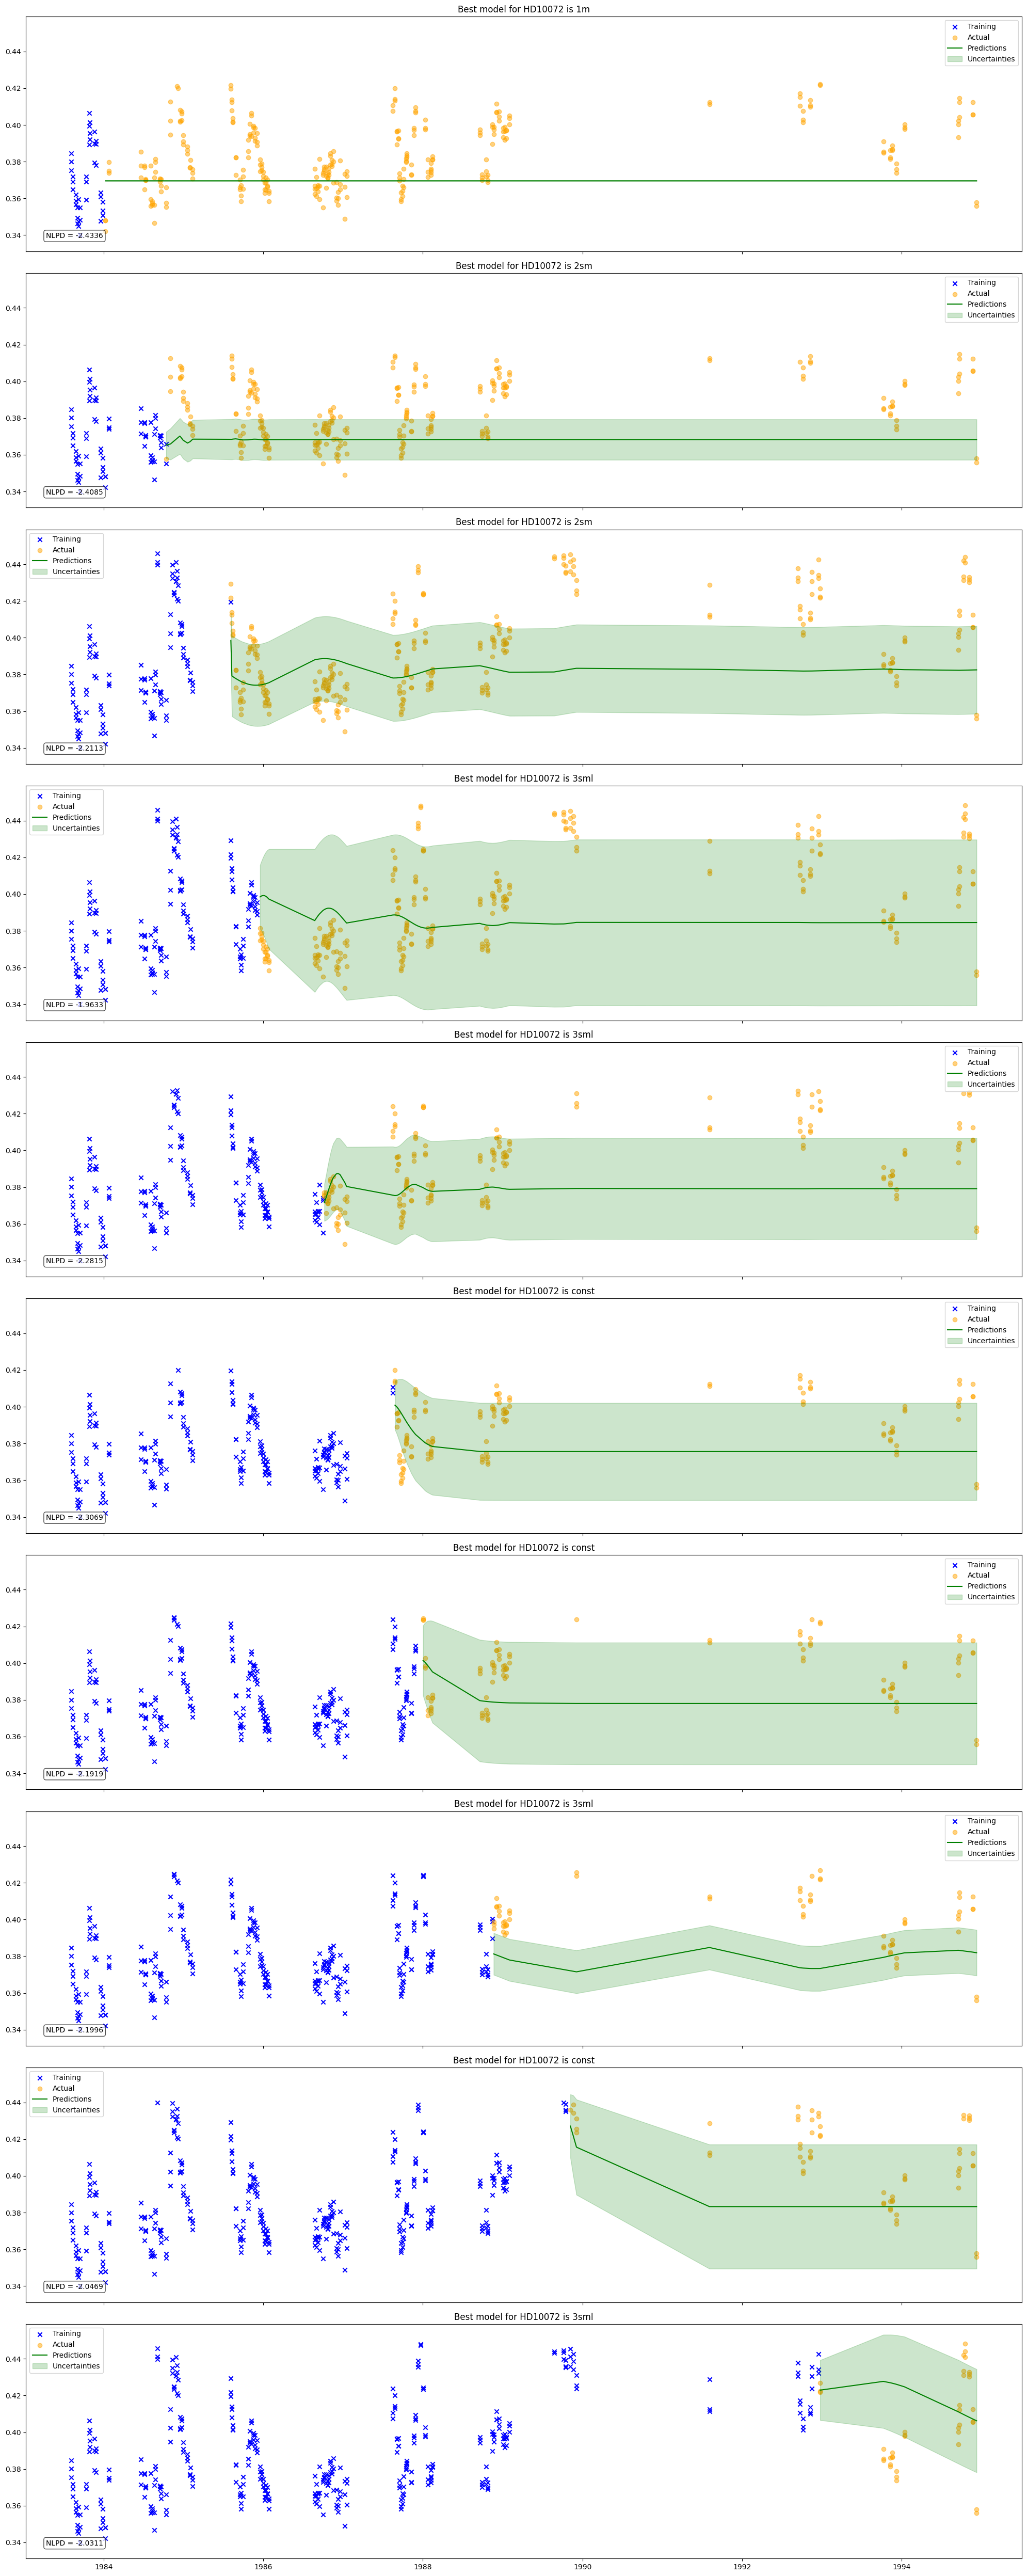

In [ ]:
# Window analysis using refactored train_gpr
def plot_moving_window_refactored(n_windows=10, train_low=0.1, train_high=0.9):
    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, ts in enumerate(train_splits):
        print(f"{idx+1}/{n_windows}")
        train_gpr(
            datapath         = datapath,
            add_prefix       = add_prefix,
            relative         = relative,
            train_split      = ts,
            valid_split      = 0.99 - ts,
            star_name        = star_name,
            star_type        = star_type,
            error_percent    = error_percent,
            sigma_upper_mult = sigma_upper_mult,
            q_bounds_in      = q_bounds_in,
            require_mid      = require_mid,
            verbose          = False,
            plot             = False,
            loop_verbose     = loop_verbose,
            loop_plot        = loop_plot,
            loop_savefigs    = loop_savefigs,
            results_verbose  = results_verbose,
            results_plot     = results_plot,
            ax               = axes[idx],
            SEED             = SEED,
        )

    plt.tight_layout()
    plt.savefig(f"moving_window_refactored_{star_name}")
    plt.show()

plot_moving_window_refactored()

- I think that this star maybe just doesn't have enough data to make a good prediction. 
- How can we flag data quality as a limiting factor.
- The bumps in the code are bc the plotting only evaluates at times with data. Update the code to make it plot everywhere at the rate 1/day (can be changed).

In [ ]:
from helpers.priors import SM2016_m_to_s, SM2016_s_to_m

def get_priors(classified_signal_data, star_type, verbose = True,
                        direct_bound_tol = 0.05, # For regular go between 0.95 and 1.05
                        sm2016_bound_tol = 0.2, # 0.8 to 1.2
                        mean_bound_tol = 1, # 1 std: make sure to correct for lower bound max(0, mean-meanboundtol*std)
               ):
        '''
        This takes in the input of the find_classify_signals function
        and outputs the three priors. One in each range.count
        Fills in missing ones using the SM2016 relationship.
        Fills in missing long-term priors with 100 year guess.

        Returns the priors and the bounds. Bounds are based on what tolerance we want for mean and SM2016.
        Mean comes from a table with stds. Define mean bounds as standard deviations allowed.
        SM2016 should be percentage based.
        '''
        #------- Define the means and standard deviations that are fallbacks------------
        mu_Pmids = { # THESE COME FROM SM2016
        'F':  {'mean_yr': 9.5,  'mean_days': 9.5  * 365, 'std_yr': 5.3, 'std_days': 5.3 * 365},
        'G':  {'mean_yr': 6.7,  'mean_days': 6.7  * 365, 'std_yr': 3.6, 'std_days': 3.6 * 365},
        'K':  {'mean_yr': 8.5,  'mean_days': 8.5  * 365, 'std_yr': 3.6, 'std_days': 3.6 * 365},
        'ME': {'mean_yr': 6.0,  'mean_days': 6.0  * 365, 'std_yr': 2.9, 'std_days': 2.9 * 365},
        'MM': {'mean_yr': 7.1,  'mean_days': 7.1  * 365, 'std_yr': 2.7, 'std_days': 2.7 * 365},
        }  # P_cyc


        mu_Pshorts = {  # THESE COME FROM SM2016
        'F':  {'mean_yr': 8.6  / 365, 'mean_days': 8.6,  'std_yr': 6.2  / 365, 'std_days': 6.2},
        'G':  {'mean_yr': 19.6 / 365, 'mean_days': 19.6, 'std_yr': 11.1 / 365, 'std_days': 11.1},
        'K':  {'mean_yr': 27.4 / 365, 'mean_days': 27.4, 'std_yr': 15.7 / 365, 'std_days': 15.7},
        'ME': {'mean_yr': 36.2 / 365, 'mean_days': 36.2, 'std_yr': 29.9 / 365, 'std_days': 29.9},
        'MM': {'mean_yr': 85.4 / 365, 'mean_days': 85.4, 'std_yr': 53.4 / 365, 'std_days': 53.4},
        }  # P_rot

        #------ Now choose which ones to return----------

        # If has all three then return all three
        short = classified_signal_data.get('short', np.nan)
        mid = classified_signal_data.get('mid', np.nan)
        long = classified_signal_data.get('long', np.nan)

        # Use detected if available, otherwise use SM2016 if available, else use mean for that star type
        def _resolve(direct, derive, default, std):
                # If there is a direct detection from LSP method
                if not np.isnan(direct):
                        direct_bounds = [direct * (1 - direct_bound_tol), direct * (1 + direct_bound_tol)]
                        return direct, direct_bounds, 'found'
                
                # Otherwise check if SM2016 possible
                derived = derive()

                if derived is not None: #SM2016
                        sm2016_bounds = [derived * (1 - sm2016_bound_tol), derived * (1 + sm2016_bound_tol)]
                        return derived, sm2016_bounds, 'SM2016'
                
                # Otherwise use mean as defined in paper
                default_bounds = [max(1, default - (mean_bound_tol * std)), default + (mean_bound_tol * std)]

                return default, default_bounds, 'mean'

        short_val, short_bounds, short_src = _resolve(
                                                short,
                                                lambda: SM2016_m_to_s(mid, star_type) if not np.isnan(mid) else None,
                                                mu_Pshorts[star_type]['mean_days'], std = mu_Pshorts[star_type]['std_days']
                                                )
        mid_val, mid_bounds, mid_src = _resolve(
                                                mid,
                                                lambda: SM2016_s_to_m(short, star_type) if not np.isnan(short) else None,
                                                mu_Pmids[star_type]['mean_days'], std = mu_Pmids[star_type]['std_days']
                                                )
        long_val, long_bounds, long_src = _resolve(
                                                long, 
                                                lambda: None, 
                                                100 * 365, std = 100*365
                                                )

        #------Form priors and bounds to return--------

        rho_priors = {'short': short_val, 'mid': mid_val, 'long': long_val}

        # These are prios on periods so they are limited by rho_bounds
        rho_bounds = {'short': short_bounds, 'mid': mid_bounds, 'long': long_bounds}

        # Sources
        sources = {'short': short_src, 'mid': mid_src, 'long': long_src}

        if verbose:
                table = PrettyTable(["Cycle Type", "Prior Days", "Prior Years", "Bounds Days", "Bounds Years", "Source"])
                table.add_row(["Short", f"{rho_priors.get('short'):.2f}", f"{rho_priors.get('short')/365:.2f}", f"{rho_bounds.get('short')}", f"({rho_bounds.get('short')[0]/365:.2f}, {rho_bounds.get('short')[1]/365:.2f})", short_src])
                table.add_row(["Mid",   f"{rho_priors.get('mid'):.2f}",   f"{rho_priors.get('mid')/365:.2f}",   f"{rho_bounds.get('mid')}",   f"({rho_bounds.get('mid')[0]/365:.2f}, {rho_bounds.get('mid')[1]/365:.2f})",   mid_src])
                table.add_row(["Long",  f"{rho_priors.get('long'):.2f}",  f"{rho_priors.get('long')/365:.2f}",  f"{rho_bounds.get('long')}",  f"({rho_bounds.get('long')[0]/365:.2f}, {rho_bounds.get('long')[1]/365:.2f})",  long_src])
                print(table)

        return rho_priors, rho_bounds, sources 


def train_gpr(
        datapath, 
        direct_bound_tol = 0.1, sm2016_bound_tol = 0.2, 
        mean_bound_tol = 1, # in std
        add_prefix: bool = False, # whether or not to add the 240000 to the JD
        train_split: float = 0.8, valid_split: float = 0.19,
        star_type: str = None, star_name: str = None,
        error_percent: float = 2.5, # the percentage error of the input
        sigma_upper_mult: float = 5.0, q_bounds_in = [5, 100],
        relative: bool = True, # Plot data with relative dates
        verbose = True, plot = True, # general outputs
        loop_verbose: bool = False, loop_plot: bool = False, loop_savefigs: bool = True, # output within the loop
        results_verbose: bool = True, results_plot: bool = True, ax = None, # output the results
        result_plot_cadence = 1, # Plot every x days
        result_plot_extra = 100, # Plot for 100 days extra after end of validation set
        require_mid: bool = True, # discard kernel combos with no mid-range term (prevents underfitting with sparse data)
        SEED = 1701
        ):
      
        # Read the data into a "raw" df
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

        # Prep the df adds the column names etc
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

        # Split the data
        dirty_train_df, dirty_valid_df, test_df = split_df(data_df,
                                                     train_split=train_split, valid_split=valid_split)

        # Clean the dataset for outliers
        train_df, valid_df, _ = clean_df(dirty_train_df, dirty_valid_df, tol=4,
                                verbose=verbose, plot=plot)

        # Classify signal data and get priors
        classified_signal_data = find_classify_signals(dirty_train_df,
                                                plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                                plot_genpriors=plot, verbose_genpriors=verbose)
        
        rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                                        star_type=star_type,
                                                                        direct_bound_tol = direct_bound_tol, 
                                                                        sm2016_bound_tol = sm2016_bound_tol, 
                                                                        mean_bound_tol = mean_bound_tol,
                                                                        verbose=verbose)

        #-----Do the model training and comparison---------
        train_yerr = train_df['sind'] * error_percent / 100

        train_mean = train_df['sind'].mean()
        train_std  = train_df['sind'].std()

        # Define the prior combos to try (k, [[q_priors], [rho_priors]])
        prior_combos = {
                "1s":    {'k': 1, 'q_priors': None,          'cycle_keys': ['short']},
                "1m":    {'k': 1, 'q_priors': None,          'cycle_keys': ['mid']},
                "1l":    {'k': 1, 'q_priors': None,          'cycle_keys': ['long']},

                "2sm":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'mid']},
                "2ml":   {'k': 2, 'q_priors': None,          'cycle_keys': ['mid',   'long']},
                "2sl":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'long']},

                "3sml":  {'k': 3, 'q_priors': None,          'cycle_keys': ['short', 'mid', 'long']},

                "const": {'k': 1, 'q_priors': "overdamped",  'cycle_keys': ['mid']},
        }

        if require_mid:
                prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

        # Set up the loop
        best_combo  = None
        best_NLPD   = np.inf
        best_gp     = None
        best_params = None

        # Run the loop
        for combo_name, combo_info in prior_combos.items():
                k = combo_info['k']
                q_prior_type = combo_info['q_priors']
                cycle_keys = combo_info['cycle_keys']
                
                np.random.seed(SEED)

                #---- q priors----
                if q_prior_type == 'overdamped':
                        q_0s     = [np.random.uniform(0, 0.5) for _ in range(k)]
                else:
                        q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

                #---remaining priors----
                sigma_0s = [train_std / k for _ in range(k)]
                rho_0s = [rho_priors[cycle_key] for cycle_key in cycle_keys]

                initial_guess = np.concatenate([
                        np.log(sigma_0s),
                        np.log(rho_0s),
                        np.log(q_0s)
                ])

                #----q bounds-----
                if q_prior_type == 'overdamped':
                        q_bounds     = [(-np.inf, np.log(0.5)) for _ in range(k)]
                else:
                        q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

                sigma_upper  = train_std * sigma_upper_mult
                sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
                rho_bounds   = np.log([rho_prior_bounds[cycle_key] for cycle_key in cycle_keys])

                bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

                # Create the initial kernel for this iteration
                kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                for k_idx in range(1, k):
                        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

                # Define and compute the GP
                gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                gp.compute(train_df['day'], yerr=train_yerr)

                # Train the GP
                gp_results = minimize(
                        NLL, initial_guess,
                        args=(gp, k, train_df['sind'].to_numpy()),
                        method='L-BFGS-B',
                        bounds=bounds
                        )

                gp   = set_params(gp_results.x, k, gp)
                gp.recompute()
                best = np.exp(gp_results.x)

                if loop_verbose:
                        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                        best_sigmas = best[0:k]
                        best_rhos   = best[k:2*k]
                        best_qs     = best[2*k:]
                        for k_idx in range(k):
                                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                               f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                        print(gp_results.success, gp_results.message)
                        print(f"For k = {k}")
                        print(table)

                # Predict on validation set
                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                std = np.sqrt(cov)

                # Model comparison via NLPD
                y_valid    = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var  = cov + valid_yerr**2
                nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
                mean_nlpd = nlpd_per_point.mean()

                if mean_nlpd < best_NLPD:
                        best_combo  = combo_name
                        best_NLPD   = mean_nlpd
                        best_gp     = gp
                        best_params = best

                if loop_plot:
                        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                        
                        loop_ax.set_title(star_name + " " + combo_name)

                        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                        loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                             color='green', alpha=0.2, label='Uncertainties')
                        
                        loop_ax.legend()

                        loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                                transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                        
                        if loop_savefigs:
                                loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                                plt.close(loop_fig)

                        else:
                                plt.show()

                if loop_verbose:
                        print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")

        #-------Now we have the best model------

        # Predict on a dense regular grid for smooth plotting
        t_start = valid_df['day'].iloc[0]
        t_end   = valid_df['day'].iloc[-1] + result_plot_extra
        sampled_days = np.arange(t_start, t_end, result_plot_cadence)

        mu, cov = best_gp.predict(train_df['sind'], t=sampled_days, return_var=True)
        std = np.sqrt(cov)
        results = pd.DataFrame({
                'forecast': mu,
                'lower':    mu - std,
                'upper':    mu + std,
        }, index=sampled_days)

        # Convert sampled days to years for plotting
        day_ref       = train_df['day'].iloc[0]
        year_ref      = train_df['year'].iloc[0]
        sampled_years = year_ref + (sampled_days - day_ref) / 365.25

        if results_verbose: # Print best model params
                print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
                k = prior_combos[best_combo]['k']
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best_params[0:k]
                best_rhos   = best_params[k:2*k]
                best_qs     = best_params[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                       f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(table)

        if results_plot: # Plot best model predictions
                if ax is None: # Enables passthrough
                        fig, ax = plt.subplots(figsize=(20, 5))
                ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)

                ax.set_title(f"Best model for {star_name} is {best_combo}")
                ax.plot(sampled_years, results['forecast'], color='green', label='Predictions')
                ax.fill_between(sampled_years, results['lower'], results['upper'],
                                color='green', alpha=0.2, label='Uncertainties')
                ax.legend()
                ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        return best_gp

1/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 777.92 days was accepted.
In iteration 1, period at 106.68 days was accepted.
The best params were found for 1m with NLPD of -2.4335898500278637.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0001 | 5.00 |   700.13   |     1.92    |
+--------+------+------------+-------------+
2/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 36493.79 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36492.70 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36490.51 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36489.78 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36485.76 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36484.30 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.84 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.11 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36480.29 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36475.91 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at pe

...

Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1269.21 days was accepted.
Peak at period 124.93 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 186.62 days was identified to be a window of 182.62 days by tolerance 0.02.
Peak at period 353.06 days was identified to be a window of 365.25 days by tolerance 0.03.
Period of 66.53 days has SNR of 4.085637689917451 < 5.
Period of 99.75 days has SNR of 3.9697636476537137 < 5.
Iteration 1 did not find a frequency: terminating loop.
The best params were found for 3sml with NLPD of -2.1996364678164597.
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0107 | 10.00 |    0.05    |     0.00    |
| 0.0072 | 10.00 |  1142.29   |     3.13    |
| 0.0001 |  5.00 |  37877.90  |    103.78   |
+--------+-------+------------+-------------+
9/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 299.40 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 1, period at 772.08 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 188.81 days was identified to be an alias of 772.08 days at mult 0.25 by tolerance 0.02.
In iteration 2, period at 346.85 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 3, period at 273.49 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 559.65 days was identified to be an alias of 273.49 days at mult 2.00 by tolerance 0.02.
In iteration 4, period at 229.32 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by to

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Period of 397.22 days has SNR of 4.639367148272055 < 5.
Period of 300.50 days has SNR of 4.751720763588044 < 5.
In iteration 0, period at 1547.71 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 396.13 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.02.
In iteration 1, period at 567.68 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 399.41 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.03.
Peak at period 354.15 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 2, period at 700.54 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 350.87 days was identified to be an alias of 700.54

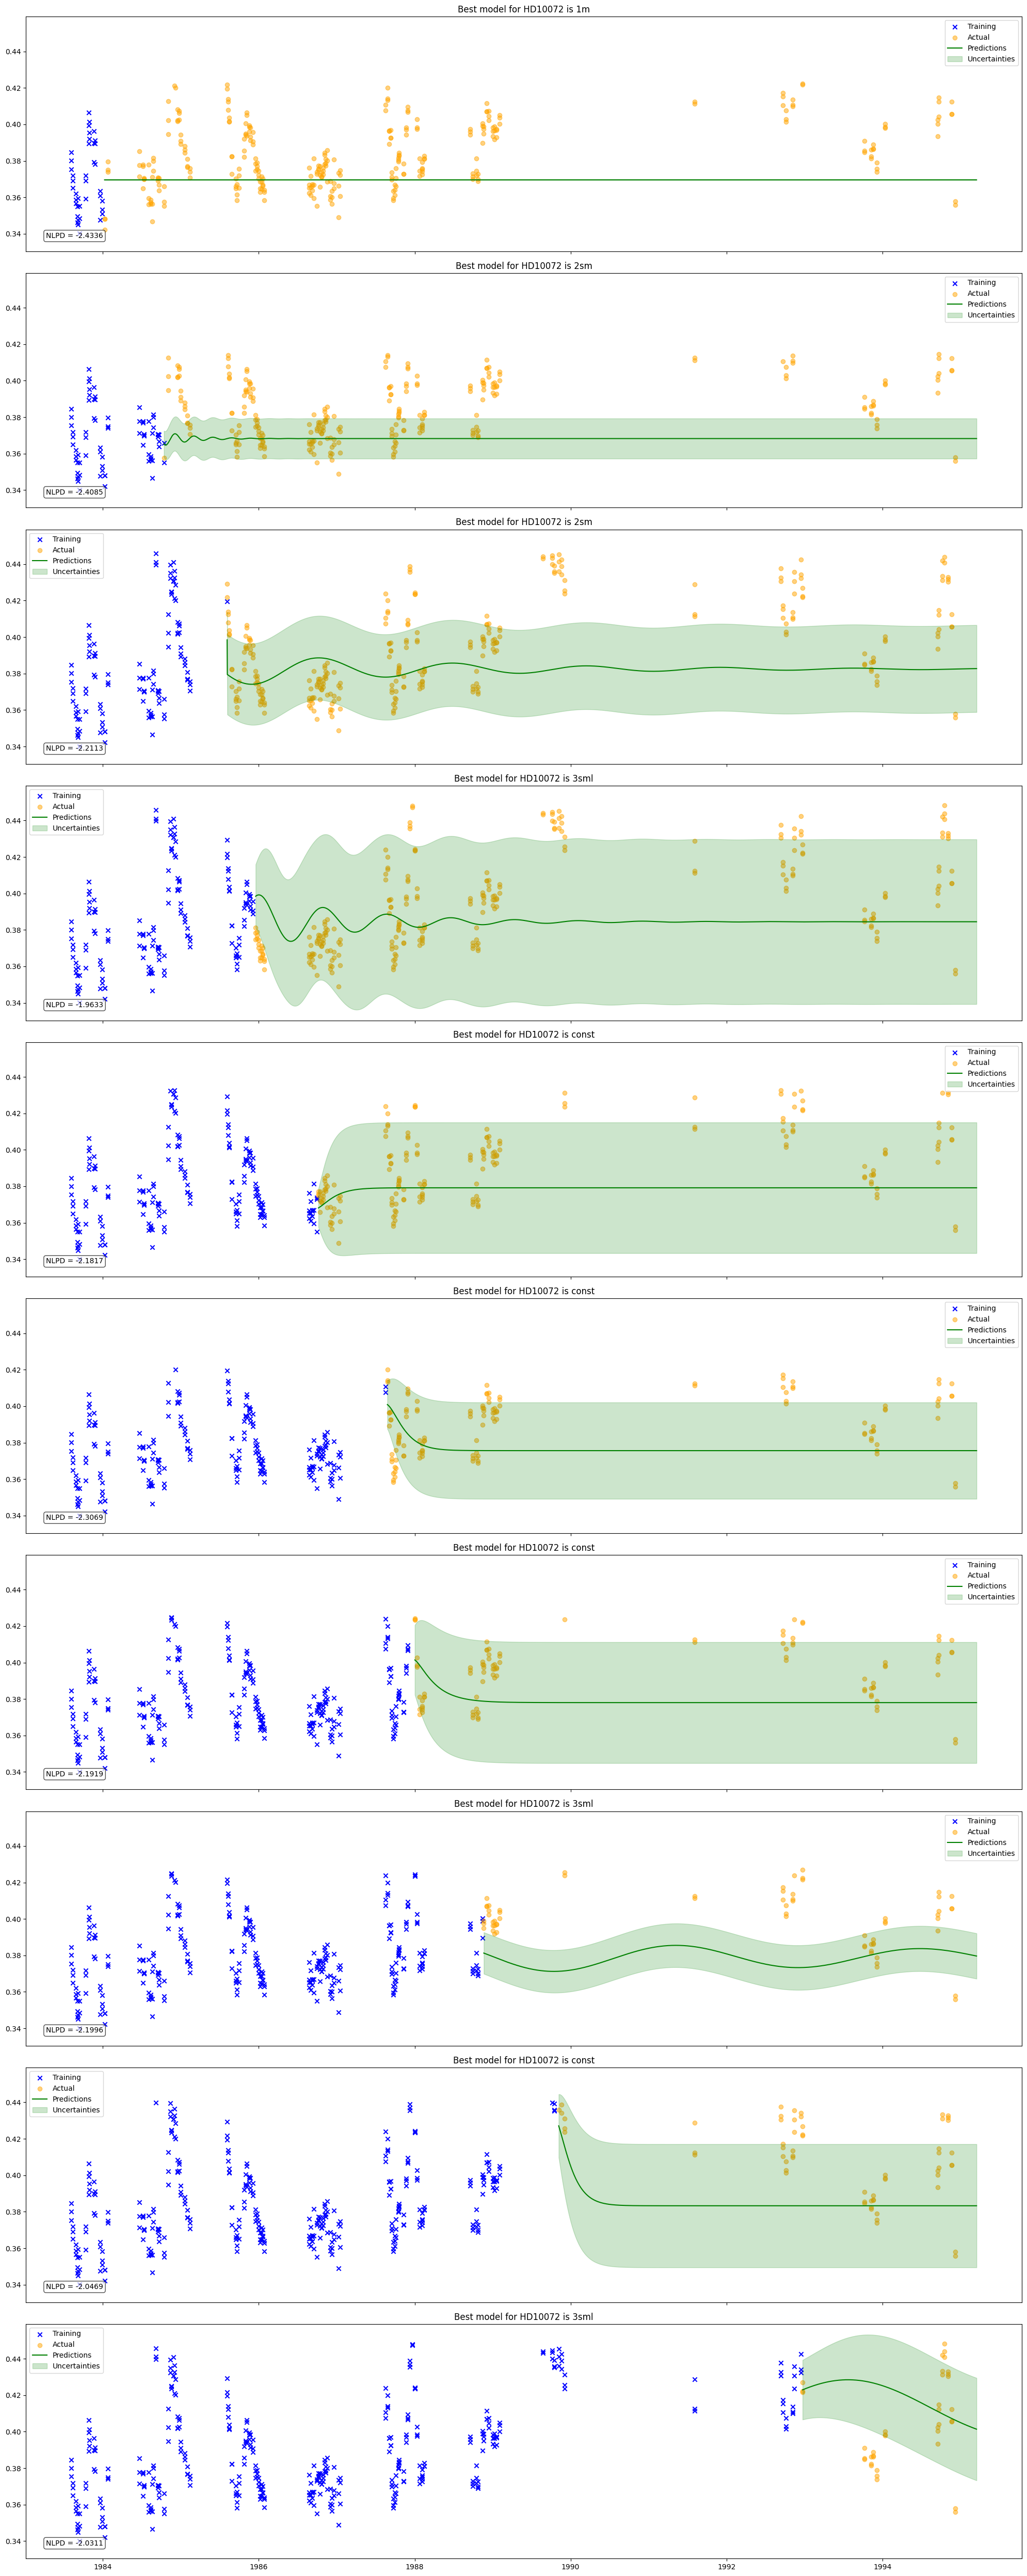

In [ ]:
# Window analysis using refactored train_gpr
def plot_moving_window_refactored(n_windows=10, train_low=0.1, train_high=0.9):
    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, ts in enumerate(train_splits):
        print(f"{idx+1}/{n_windows}")
        train_gpr(
            datapath         = datapath,
            add_prefix       = add_prefix,
            relative         = relative,
            train_split      = ts,
            valid_split      = 0.99 - ts,
            star_name        = star_name,
            star_type        = star_type,
            error_percent    = error_percent,
            sigma_upper_mult = sigma_upper_mult,
            q_bounds_in      = q_bounds_in,
            require_mid      = require_mid,
            verbose          = False,
            plot             = False,
            loop_verbose     = loop_verbose,
            loop_plot        = loop_plot,
            loop_savefigs    = loop_savefigs,
            results_verbose  = results_verbose,
            results_plot     = results_plot,
            ax               = axes[idx],
            SEED             = SEED,
        )

    plt.tight_layout()
    plt.savefig(f"moving_window_refactored_{star_name}")
    plt.show()

plot_moving_window_refactored()

- This has now all been added to the helpers library.
- We can test it.

1/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 777.92 days was accepted.
In iteration 1, period at 106.68 days was accepted.
The best params were found for 1m with NLPD of -2.4335898500278637.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0001 | 5.00 |   700.13   |     1.92    |
+--------+------+------------+-------------+
2/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 36493.79 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36492.70 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36490.51 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36489.78 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36485.76 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36484.30 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.84 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36482.11 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36480.29 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at period 36475.91 days is greater than maximum detectable period of 2372.6999999997206 days.
Peak at pe

...

Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 1269.21 days was accepted.
Peak at period 124.93 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 186.62 days was identified to be a window of 182.62 days by tolerance 0.02.
Peak at period 353.06 days was identified to be a window of 365.25 days by tolerance 0.03.
Period of 66.53 days has SNR of 4.085637689917451 < 5.
Period of 99.75 days has SNR of 3.9697636476537137 < 5.
Iteration 1 did not find a frequency: terminating loop.
The best params were found for 3sml with NLPD of -2.1996364678164597.
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0107 | 10.00 |    0.05    |     0.00    |
| 0.0072 | 10.00 |  1142.29   |     3.13    |
| 0.0001 |  5.00 |  37877.90  |    103.78   |
+--------+-------+------------+-------------+
9/10


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 0, period at 299.40 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 1, period at 772.08 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 188.81 days was identified to be an alias of 772.08 days at mult 0.25 by tolerance 0.02.
In iteration 2, period at 346.85 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
In iteration 3, period at 273.49 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 559.65 days was identified to be an alias of 273.49 days at mult 2.00 by tolerance 0.02.
In iteration 4, period at 229.32 days was accepted.
Peak at period 125.66 days was identified to be a window of 121.75 days by to

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Period of 397.22 days has SNR of 4.639367148272055 < 5.
Period of 300.50 days has SNR of 4.751720763588044 < 5.
In iteration 0, period at 1547.71 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 396.13 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.02.
In iteration 1, period at 567.68 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 399.41 days was identified to be an alias of 1547.71 days at mult 0.25 by tolerance 0.03.
Peak at period 354.15 days was identified to be a window of 365.25 days by tolerance 0.03.
In iteration 2, period at 700.54 days was accepted.
Peak at period 125.30 days was identified to be a window of 121.75 days by tolerance 0.03.
Peak at period 350.87 days was identified to be an alias of 700.54

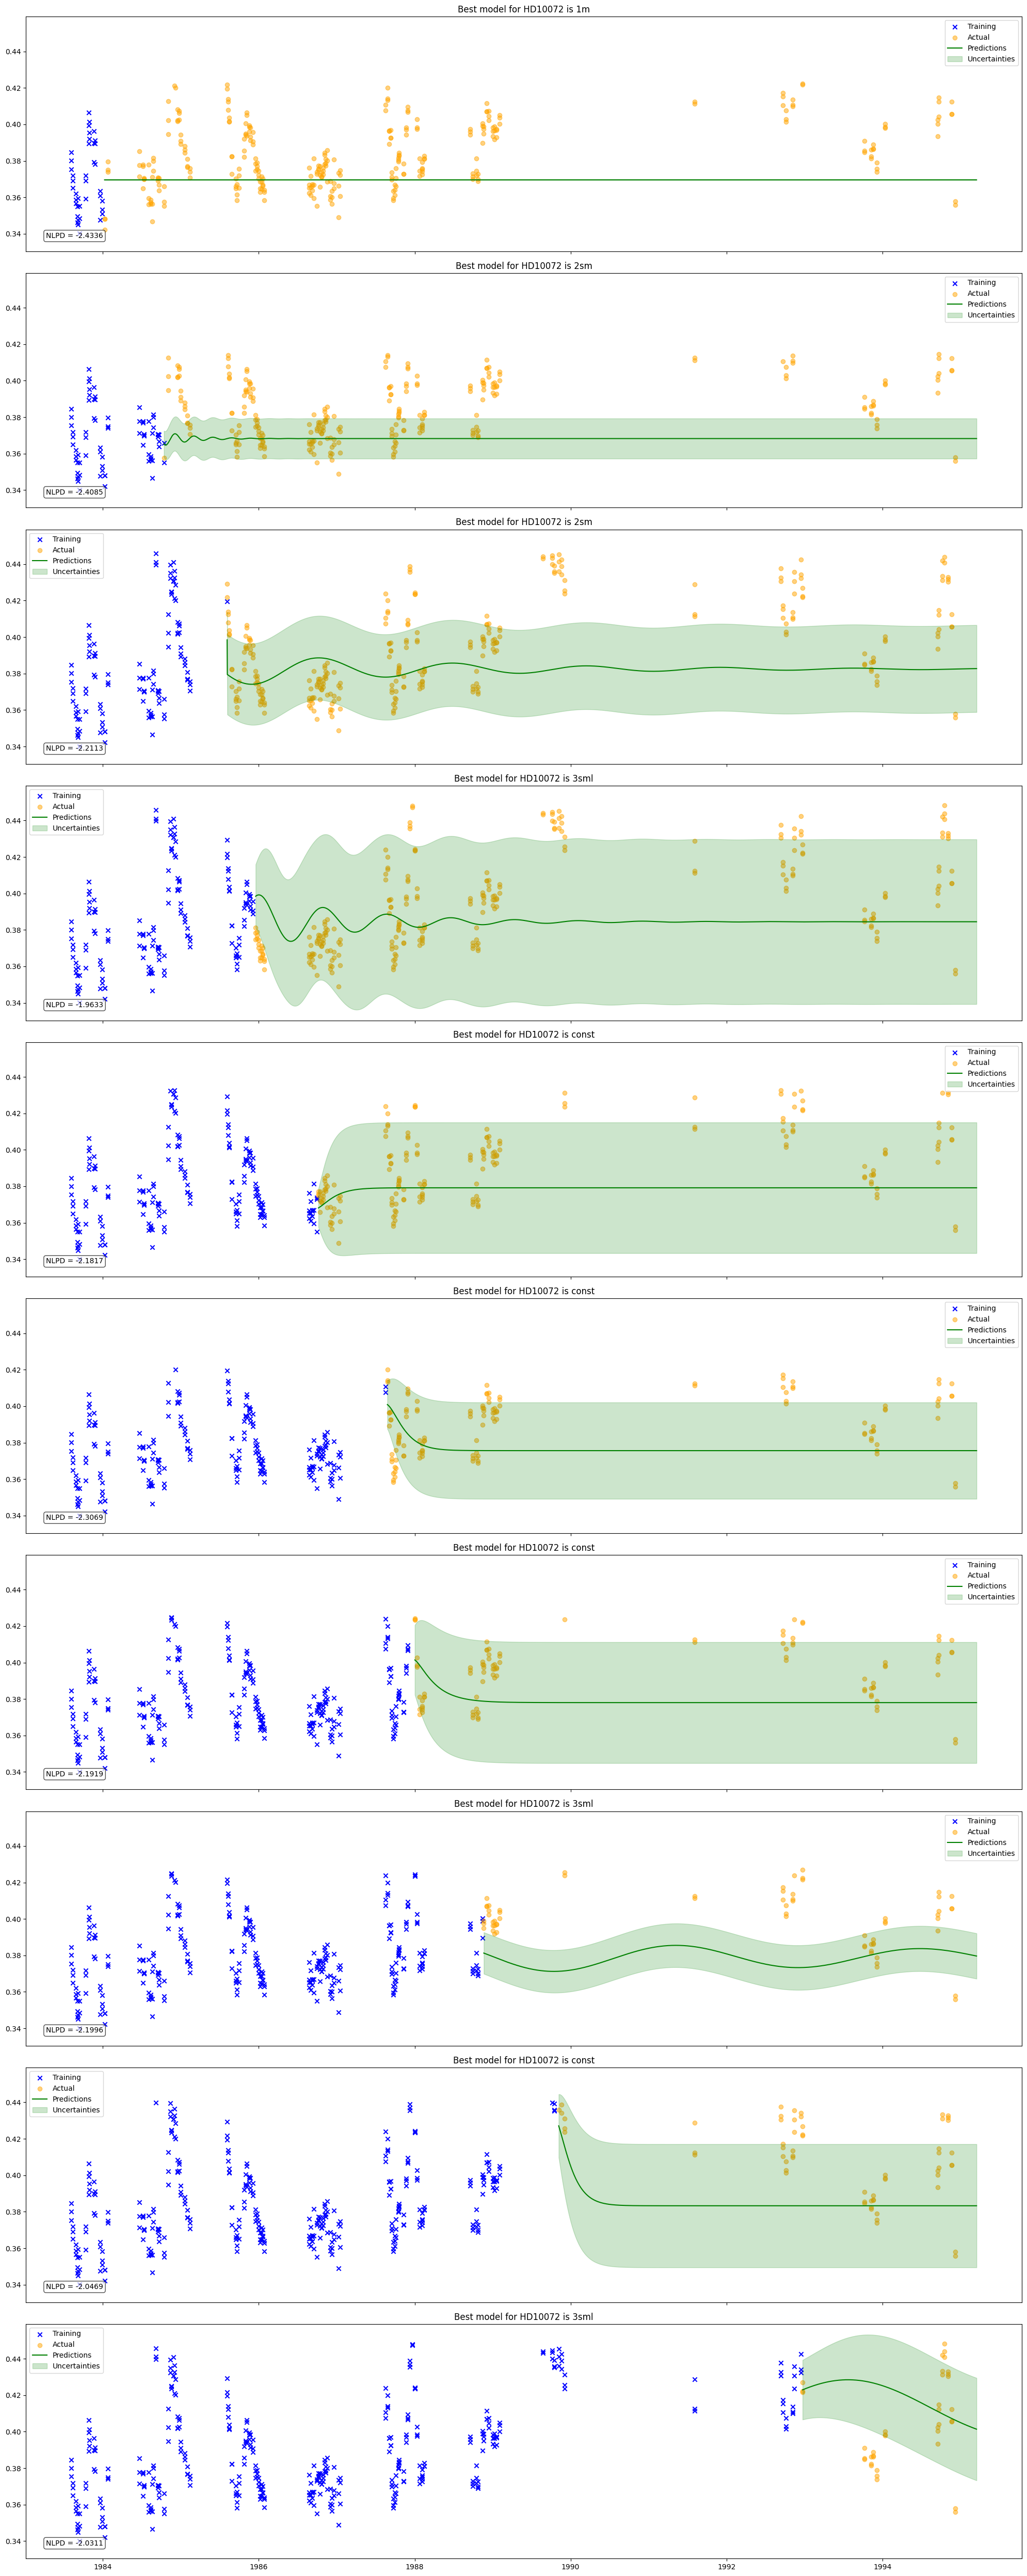

In [11]:
from helpers.gpr import train_gpr


require_mid = True
sigma_upper_mult = 5
rho_bound_mults = [0.9, 1.1]
q_bounds_in = [5, 10]
loop_verbose = False
loop_plot = False
loop_savefigs = False
star_name = "HD10072"
results_verbose = True
results_plot = True
ax = None

# Window analysis using refactored train_gpr
def plot_moving_window_refactored(n_windows=10, train_low=0.1, train_high=0.9):
    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, ts in enumerate(train_splits):
        print(f"{idx+1}/{n_windows}")
        train_gpr(
            datapath         = datapath,
            add_prefix       = add_prefix,
            relative         = relative,
            train_split      = ts,
            valid_split      = 0.99 - ts,
            star_name        = star_name,
            star_type        = star_type,
            error_percent    = error_percent,
            sigma_upper_mult = sigma_upper_mult,
            q_bounds_in      = q_bounds_in,
            require_mid      = require_mid,
            verbose          = False,
            plot             = False,
            loop_verbose     = loop_verbose,
            loop_plot        = loop_plot,
            loop_savefigs    = loop_savefigs,
            results_verbose  = results_verbose,
            results_plot     = results_plot,
            ax               = axes[idx],
            SEED             = SEED,
        )

    plt.tight_layout()
    plt.savefig(f"moving_window_refactored_{star_name}")
    plt.show()

plot_moving_window_refactored()


- Yeah ok this works. 
- I think this low data star highlights how the performance can be overconfident for low data stars. We should implement an MCMC to show the uncertainty in the kernel params.